<a href="https://colab.research.google.com/github/AishahAbdulHakeem/skincare-ai/blob/main/02_sentiment_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 Sentiment Analysis

This notebook:
- Loads raw review data from Kaggle
- Runs VADER sentiment scoring on each review
- Aggregates sentiment features per product
- Extracts representative review summaries
- Saves enriched dataset for model training

## Setup
Download review files directly from Kaggle into Colab's temporary storage.

In [ ]:
# --- Kaggle API Setup ---
# Upload your kaggle.json when prompted
os.makedirs('/root/.config/kaggle', exist_ok=True)
files.upload()  # select your kaggle.json(kaggle api key) file here

Mounted at /content/drive


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aishahabdulhakeem23","key":"7875a1591b98f8db9b42e713f6ae594e"}'}

In [ ]:
# Move it to the right place and lock permissions (Kaggle requires this)
!mv kaggle.json /root/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json

In [ ]:
# Install Kaggle if needed
!pip install kaggle -q

# Download only the review CSVs (not the whole dataset)
!kaggle datasets download -d nadyinky/sephora-products-and-skincare-reviews \
    --file reviews_0-250.csv -p /content/drive/MyDrive/skincare-ai/reviews/ --unzip

!kaggle datasets download -d nadyinky/sephora-products-and-skincare-reviews \
    --file reviews_250-500.csv -p /content/drive/MyDrive/skincare-ai/reviews/ --unzip

!kaggle datasets download -d nadyinky/sephora-products-and-skincare-reviews \
    --file reviews_500-750.csv -p /content/drive/MyDrive/skincare-ai/reviews/ --unzip

!kaggle datasets download -d nadyinky/sephora-products-and-skincare-reviews \
    --file reviews_750-1250.csv -p /content/drive/MyDrive/skincare-ai/reviews/ --unzip

!kaggle datasets download -d nadyinky/sephora-products-and-skincare-reviews \
    --file reviews_1250-end.csv -p /content/drive/MyDrive/skincare-ai/reviews/ --unzip

print("All review files downloaded to /content/drive/MyDrive/skincare-ai/reviews/")

Dataset URL: https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews
License(s): Attribution 4.0 International (CC BY 4.0)
100% 78.7M/78.7M [00:02<00:00, 33.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews
License(s): Attribution 4.0 International (CC BY 4.0)
100% 27.9M/27.9M [00:01<00:00, 22.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews
License(s): Attribution 4.0 International (CC BY 4.0)
100% 15.6M/15.6M [00:00<00:00, 16.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews
License(s): Attribution 4.0 International (CC BY 4.0)
100% 16.2M/16.2M [00:01<00:00, 16.8MB/s]

Dataset URL: https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews
License(s): Attribution 4.0 International (CC BY 4.0)
100% 7.10M/7.10M [00:00<00:00, 9.30MB/s]

All review files downloaded to /content/drive/MyDrive/skinca

## Load Data
Load the cleaned skincare products saved from Notebook 01.

In [ ]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import glob
import pickle
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import os
import zipfile
import matplotlib.pyplot as plt
from google.colab import files, drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Load the cleaned skincare product table (already filtered to skincare only)
skincare = pd.read_pickle("/content/drive/MyDrive/skincare-ai/data/processed/skincare_cleaned.pkl")

print("Skincare products:", len(skincare))
print(skincare.head(3))

Skincare products: 2420
   product_id  rating                                    ingredient_list
89    P439055  4.5413  [collagen (vegan)*, water (aqua, eau), ethylhe...
90    P421277  4.0259  [collagen (vegan)*, water (aqua, eau), propane...
91    P467602  4.5306  [aqua (water/eau), stearic acid, isopropyl iso...


In [ ]:
# The Sephora dataset comes in multiple review CSVs — load them all
target_dir = "/content/drive/MyDrive/skincare-ai/reviews/"
os.makedirs(target_dir, exist_ok=True)

# First, try to find the CSV files directly in the target directory
review_files = glob.glob(os.path.join(target_dir, "reviews_*.csv"))

# If CSV files are not found, check if the zip files are in /content/reviews/
# and unzip them to the target_dir
if not review_files:
    zip_files_location = "/content/reviews/"
    zip_files = glob.glob(os.path.join(zip_files_location, "reviews_*.csv.zip"))
    if zip_files:
        print(f"Found {len(zip_files)} zip files in {zip_files_location}. Unzipping to {target_dir}...")
        for zf in zip_files:
            with zipfile.ZipFile(zf, 'r') as zip_ref:
                zip_ref.extractall(target_dir)
        # After unzipping, try to find the CSV files again
        review_files = glob.glob(os.path.join(target_dir, "reviews_*.csv"))
    else:
        print(f"No CSV or zip files found matching patterns in {target_dir} or {zip_files_location}. Please ensure files are downloaded and unzipped.")

if not review_files:
    # If still no review files, raise an error or handle gracefully
    raise FileNotFoundError("Could not find any review CSV files after trying to locate and unzip them.")


reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)

print(f"Total reviews loaded: {len(reviews)}")
print("Columns:", reviews.columns.tolist())  # <-- check this to confirm text column name

/tmp/ipykernel_10035/2817520221.py:31: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
/tmp/ipykernel_10035/2817520221.py:31: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
/tmp/ipykernel_10035/2817520221.py:31: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)


Total reviews loaded: 1094411
Columns: ['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']


## Filter to Skincare
Keep only reviews for skincare products identified in Notebook 01.

In [ ]:
skincare_ids = set(skincare['product_id'])

reviews_skincare = reviews[reviews['product_id'].isin(skincare_ids)].copy()

print("Skincare reviews:", len(reviews_skincare))
print("Unique products covered:", reviews_skincare['product_id'].nunique())

Skincare reviews: 1094411
Unique products covered: 2351


## Sentiment Scoring
Run VADER sentiment analysis on each review. The compound score ranges
from -1 (negative) to +1 (positive).

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isna(text) or str(text).strip() == "":
        return None
    return analyzer.polarity_scores(str(text))['compound']  # -1 to +1

reviews_skincare['sentiment_score'] = reviews_skincare['review_text'].apply(get_sentiment)

print(reviews_skincare[['product_id', 'review_text', 'sentiment_score']].head())

  product_id                                        review_text  \
0    P442857  These are the only pimple patches I’ve used th...   
1    P442857  One of my ingrown hair turned inflamed and sor...   
2    P442857  I have tried 10 different acne/blemish patches...   
3    P442857  Love these for my mid-size breakouts, specifyi...   
4    P442857  Best so far - though still not particularly ef...   

   sentiment_score  
0           0.0000  
1           0.4323  
2           0.9744  
3           0.8168  
4           0.2483  


In [ ]:
def pct_positive(scores):
    valid = scores.dropna()
    if len(valid) == 0:
        return np.nan
    return (valid > 0.05).sum() / len(valid)

sentiment_features = reviews_skincare.groupby('product_id').agg(
    mean_sentiment = ('sentiment_score', 'mean'),
    pct_positive   = ('sentiment_score', pct_positive),
    review_count   = ('sentiment_score', 'count')
).reset_index()

print(sentiment_features.shape)
print(sentiment_features.head())

(2351, 4)
  product_id  mean_sentiment  pct_positive  review_count
0    P107306        0.522729      0.814229           253
1    P114902        0.598616      0.857423          1529
2     P12045        0.656845      0.883610          1684
3    P122651        0.530444      0.820000           200
4    P122661        0.612969      0.865432           810


## Merge & Handle Missing Data
Merge sentiment features onto the skincare product table.
Products with no reviews receive neutral default values.

In [ ]:
skincare_with_sentiment = skincare.merge(sentiment_features, on='product_id', how='left')

# Products with no reviews get neutral defaults
skincare_with_sentiment['mean_sentiment'] = skincare_with_sentiment['mean_sentiment'].fillna(0)
skincare_with_sentiment['pct_positive']   = skincare_with_sentiment['pct_positive'].fillna(0)
skincare_with_sentiment['review_count']   = skincare_with_sentiment['review_count'].fillna(0)

print(skincare_with_sentiment[['product_id', 'rating', 'mean_sentiment', 'pct_positive', 'review_count']].head())

  product_id  rating  mean_sentiment  pct_positive  review_count
0    P439055  4.5413        0.788318      0.953753        1319.0
1    P421277  4.0259        0.586352      0.846287        1158.0
2    P467602  4.5306        0.736180      0.945709        1142.0
3    P432045  3.8721        0.501343      0.776398         644.0
4    P311143  4.4134        0.587880      0.838583         508.0


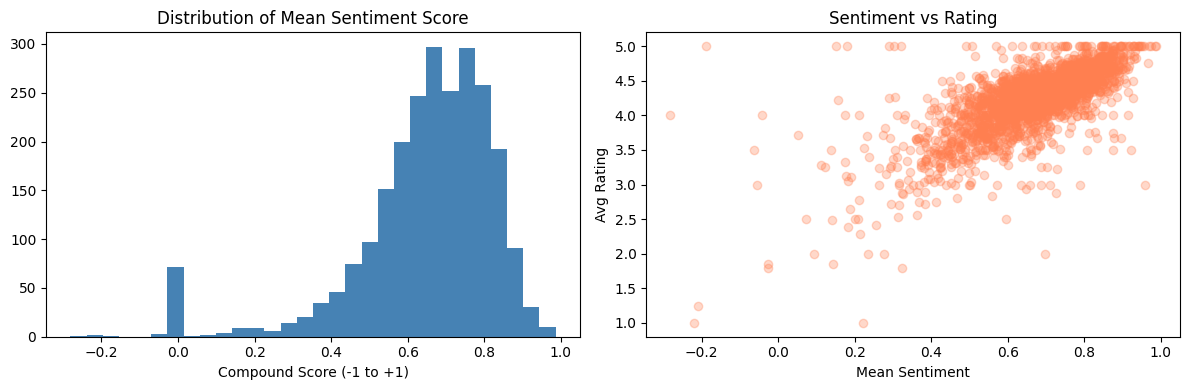

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(skincare_with_sentiment['mean_sentiment'], bins=30, color='steelblue')
axes[0].set_title('Distribution of Mean Sentiment Score')
axes[0].set_xlabel('Compound Score (-1 to +1)')

axes[1].scatter(skincare_with_sentiment['mean_sentiment'],
                skincare_with_sentiment['rating'], alpha=0.3, color='coral')
axes[1].set_title('Sentiment vs Rating')
axes[1].set_xlabel('Mean Sentiment')
axes[1].set_ylabel('Avg Rating')

plt.tight_layout()
plt.show()

## Review Summaries
Extract the most helpful reviews per product and build a short
summary to display in the app.

In [ ]:
print(reviews_skincare.columns.tolist())
print(reviews_skincare.head(3))

['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd', 'sentiment_score']
   Unnamed: 0    author_id  rating  is_recommended  helpfulness  \
0           0   2079014373       5             1.0          NaN   
1           1  12631885517       4             1.0          NaN   
2           2   2321761961       5             1.0          1.0   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                     0                         0                         0   
1                     0                         0                         0   
2                     1                         0                         1   

  submission_time                                        review_text  \
0      2023-

In [ ]:
HELPFULNESS_COL = 'total_feedback_count'
TEXT_COL        = 'review_text'

# For each product, grab the top 5 most helpful reviews
top_reviews = (
    reviews_skincare
    .sort_values(HELPFULNESS_COL, ascending=False)
    .groupby('product_id')
    .head(5)
    [['product_id', TEXT_COL, HELPFULNESS_COL]]
    .dropna(subset=[TEXT_COL])
)

print("Top reviews shape:", top_reviews.shape)
print(top_reviews.head())

Top reviews shape: (11446, 3)
       product_id                                        review_text  \
504157    P420652  There’s a lot of ridiculous things that make m...   
507420    P420652  Didn’t really notice a difference, it only sta...   
582997    P427417  I have very large pares and very oily skin. I’...   
754175    P439061  Almost all of these reviews are from people wh...   
717868    P442563  I’ve used plenty of peels and none of them see...   

        total_feedback_count  
504157                  5464  
507420                  5119  
582997                  3851  
754175                  3458  
717868                  3360  


In [ ]:
def extract_best_sentence(text):
    """Pick the longest, most informative sentence from a review."""
    if pd.isna(text) or str(text).strip() == "":
        return ""

    # Split into sentences
    sentences = re.split(r'(?<=[.!?])\s+', str(text).strip())

    # Filter out very short ones (likely noise)
    sentences = [s for s in sentences if len(s.split()) >= 6]

    if not sentences:
        return str(text)[:200]

    # Return the longest sentence (tends to be most descriptive)
    return max(sentences, key=len)

top_reviews['best_sentence'] = top_reviews[TEXT_COL].apply(extract_best_sentence)

print(top_reviews[['product_id', 'best_sentence']].head())

       product_id                                      best_sentence
504157    P420652  Also don’t recommend this to your friends beca...
507420    P420652  Didn’t really notice a difference, it only sta...
582997    P427417  I even forgot to apply my mattifying primer on...
754175    P439061  As of now, I am not seeing any difference betw...
717868    P442563  this product took care of the texture in two u...


In [ ]:
def build_summary(group):
    sentences = group['best_sentence'].tolist()
    # Join up to 3 best sentences into one summary paragraph
    summary = " ".join(sentences[:3])
    # Trim to 500 chars max so the app doesn't display a wall of text
    return summary[:500].rsplit(' ', 1)[0] + '...' if len(summary) > 500 else summary

review_summaries = (
    top_reviews
    .groupby('product_id')
    .apply(build_summary)
    .reset_index()
)
review_summaries.columns = ['product_id', 'review_summary']

print("Products with summaries:", len(review_summaries))
print()
print("Sample summary:")
print(review_summaries.iloc[0]['review_summary'])

Products with summaries: 2351

Sample summary:
On the main description page it explicitly states “What it is formulated WITHOUT: Parabens, Sulfates, Phthalates.“ However, the ingredients include both methylparaben and propylparaben. And the directions on it say to FOLLOW with a moisturizer after applying.Note also that this was developed for women undergoing “hormonal aging“, which primarily means experiencing peri-menopause and menopause. Let’s put it this way...I just had a baby and haven’t slept in a week but I’ve gotten multiple...


/tmp/ipykernel_10035/2842774501.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(build_summary)


In [ ]:
# Merge into the main skincare dataframe
skincare_final = skincare_with_sentiment.merge(
    review_summaries, on='product_id', how='left'
)

# Fill products with no reviews
skincare_final['review_summary'] = skincare_final['review_summary'].fillna(
    "No reviews available for this product."
)

print("Final dataframe shape:", skincare_final.shape)
print("Columns:", skincare_final.columns.tolist())

skincare_final.to_pickle(
    "/content/drive/MyDrive/skincare-ai/data/processed/skincare_final.pkl"
)
print("\nSaved: skincare_final.pkl")

Final dataframe shape: (2420, 7)
Columns: ['product_id', 'rating', 'ingredient_list', 'mean_sentiment', 'pct_positive', 'review_count', 'review_summary']

Saved: skincare_final.pkl


In [ ]:
summary_lookup = dict(zip(
    skincare_final['product_id'],
    skincare_final['review_summary']
))

with open("/content/drive/MyDrive/skincare-ai/models/review_summaries.pkl", "wb") as f:
    pickle.dump(summary_lookup, f)

print("Saved: review_summaries.pkl")
print("Products with summaries:", sum(1 for v in summary_lookup.values()
                                       if v != "No reviews available for this product."))

Saved: review_summaries.pkl
Products with summaries: 2351
